# 📊 Sales and Profit Analysis Across Regions and Categories

**Level:** Intermediate

**Objective:** Perform a structured EDA to understand which regions, categories and sub-categories drive revenue and profit, and identify underperforming segments.

**Tools:** pandas, matplotlib, seaborn

---

## 1. Import Libraries & Load Data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['font.size'] = 12

print('✅ Libraries imported successfully')

✅ Libraries imported successfully


In [2]:
# Load dataset
df = pd.read_csv('Sample - Superstore.csv', encoding='latin1')

print(f'Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'\nColumns:')
for i, col in enumerate(df.columns, 1):
    print(f'  {i:>2}. {col:<20} ({df[col].dtype})')

df.head()

Dataset shape: 9,994 rows × 21 columns

Columns:
   1. Row ID               (int64)
   2. Order ID             (object)
   3. Order Date           (object)
   4. Ship Date            (object)
   5. Ship Mode            (object)
   6. Customer ID          (object)
   7. Customer Name        (object)
   8. Segment              (object)
   9. Country              (object)
  10. City                 (object)
  11. State                (object)
  12. Postal Code          (int64)
  13. Region               (object)
  14. Product ID           (object)
  15. Category             (object)
  16. Sub-Category         (object)
  17. Product Name         (object)
  18. Sales                (float64)
  19. Quantity             (int64)
  20. Discount             (float64)
  21. Profit               (float64)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


## 2. Data Quality Check

In [3]:
print('='*60)
print('MISSING VALUES')
print('='*60)
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else 'No missing values ✅')
print(f'Total missing: {missing.sum()}')

print('\n' + '='*60)
print('DUPLICATE ROWS')
print('='*60)
print(f'Duplicates: {df.duplicated().sum()}')

print('\n' + '='*60)
print('DATA TYPES')
print('='*60)
print(df.dtypes)

MISSING VALUES
No missing values ✅
Total missing: 0

DUPLICATE ROWS
Duplicates: 0

DATA TYPES
Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code        int64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object


In [4]:
# Descriptive statistics
print('DESCRIPTIVE STATISTICS')
print('='*80)
df[['Sales', 'Quantity', 'Discount', 'Profit']].describe().round(2)

DESCRIPTIVE STATISTICS


,Sales,Quantity,Discount,Profit
count,9994.00,9994.00,9994.00,9994.00
mean,229.86,3.79,0.16,28.66
std,623.25,2.23,0.21,234.26
min,0.44,1.00,0.00,-6599.98
25%,17.28,2.00,0.00,1.73
50%,54.49,3.00,0.20,8.67
75%,209.94,5.00,0.20,29.36
max,22638.48,14.00,0.80,8399.98


## 3. Data Preprocessing

Convert date columns and calculate shipping duration.

In [5]:
# Convert Order Date and Ship Date to datetime
df['Order Date'] = pd.to_datetime(df['Order Date'], format='mixed')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='mixed')

# Calculate days to ship
df['days_to_ship'] = (df['Ship Date'] - df['Order Date']).dt.days

# Extract year and month
df['year'] = df['Order Date'].dt.year
df['month'] = df['Order Date'].dt.month
df['year_month'] = df['Order Date'].dt.to_period('M')

print('✅ Date conversion complete')
print(f'Date range: {df["Order Date"].min().strftime("%Y-%m-%d")} → {df["Order Date"].max().strftime("%Y-%m-%d")}')
print(f'Years: {sorted(df["year"].unique())}')
print(f'Average days to ship: {df["days_to_ship"].mean():.1f} days')

df[['Order ID', 'Order Date', 'Ship Date', 'days_to_ship', 'year']].head()

✅ Date conversion complete
Date range: 2014-01-03 → 2017-12-30
Years: [np.int32(2014), np.int32(2015), np.int32(2016), np.int32(2017)]
Average days to ship: 4.0 days


,Order ID,Order Date,Ship Date,days_to_ship,year
0,CA-2016-152156,2016-11-08,2016-11-11,3,2016
1,CA-2016-152156,2016-11-08,2016-11-11,3,2016
2,CA-2016-138688,2016-06-12,2016-06-16,4,2016
3,US-2015-108966,2015-10-11,2015-10-18,7,2015
4,US-2015-108966,2015-10-11,2015-10-18,7,2015


## 4. Multi-Level Aggregation

Group by **Region**, **Category**, and **Sub-Category** — compute Sales and Profit.

In [6]:
# ─── 4.1 Sales & Profit by REGION ───
region_agg = df.groupby('Region').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Order_Count=('Order ID', 'nunique'),
    Avg_Discount=('Discount', 'mean')
).round(2).sort_values('Total_Sales', ascending=False)

region_agg['Profit_Margin_%'] = (region_agg['Total_Profit'] / region_agg['Total_Sales'] * 100).round(2)

print('📊 SALES & PROFIT BY REGION')
print('='*80)
region_agg

📊 SALES & PROFIT BY REGION


,Total_Sales,Total_Profit,Order_Count,Avg_Discount,Profit_Margin_%
Region,,,,,
West,725457.82,108418.45,1611,0.11,14.94
East,678781.24,91522.78,1401,0.15,13.48
Central,501239.89,39706.36,1175,0.24,7.92
South,391721.90,46749.43,822,0.15,11.93


In [7]:
# ─── 4.2 Sales & Profit by CATEGORY ───
category_agg = df.groupby('Category').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Order_Count=('Order ID', 'nunique'),
    Avg_Discount=('Discount', 'mean')
).round(2).sort_values('Total_Sales', ascending=False)

category_agg['Profit_Margin_%'] = (category_agg['Total_Profit'] / category_agg['Total_Sales'] * 100).round(2)

print('📊 SALES & PROFIT BY CATEGORY')
print('='*80)
category_agg

📊 SALES & PROFIT BY CATEGORY


,Total_Sales,Total_Profit,Order_Count,Avg_Discount,Profit_Margin_%
Category,,,,,
Technology,836154.03,145454.95,1544,0.13,17.40
Furniture,741999.80,18451.27,1764,0.17,2.49
Office Supplies,719047.03,122490.80,3742,0.16,17.04


In [8]:
# ─── 4.3 Sales & Profit by SUB-CATEGORY ───
subcat_agg = df.groupby('Sub-Category').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Order_Count=('Order ID', 'nunique'),
    Avg_Discount=('Discount', 'mean')
).round(2).sort_values('Total_Profit', ascending=False)

subcat_agg['Profit_Margin_%'] = (subcat_agg['Total_Profit'] / subcat_agg['Total_Sales'] * 100).round(2)

print('📊 SALES & PROFIT BY SUB-CATEGORY')
print('='*80)
subcat_agg

📊 SALES & PROFIT BY SUB-CATEGORY


,Total_Sales,Total_Profit,Order_Count,Avg_Discount,Profit_Margin_%
Sub-Category,,,,,
Copiers,149528.03,55617.82,68,0.16,37.20
Phones,330007.05,44515.73,814,0.15,13.49
Accessories,167380.32,41936.64,718,0.08,25.05
Paper,78479.21,34053.57,1191,0.07,43.39
Binders,203412.73,30221.76,1316,0.37,14.86
Chairs,328449.10,26590.17,576,0.17,8.10
Storage,223843.61,21278.83,777,0.07,9.51
Appliances,107532.16,18138.01,451,0.17,16.87
Furnishings,91705.16,13059.14,877,0.14,14.24


In [9]:
# ─── 4.4 Multi-Level: Region × Category ───
multi_agg = df.groupby(['Region', 'Category']).agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum')
).round(2)

multi_agg['Profit_Margin_%'] = (multi_agg['Total_Profit'] / multi_agg['Total_Sales'] * 100).round(2)

print('📊 MULTI-LEVEL: REGION × CATEGORY')
print('='*70)
multi_agg

📊 MULTI-LEVEL: REGION × CATEGORY


Total_Sales  Total_Profit  Profit_Margin_%
Region  Category                                                   
Central Furniture          163797.16      -2871.05            -1.75
        Office Supplies    167026.42       8879.98             5.32
        Technology         170416.31      33697.43            19.77
East    Furniture          208291.20       3046.17             1.46
        Office Supplies    205516.06      41014.58            19.96
        Technology         264973.98      47462.04            17.91
South   Furniture          117298.68       6771.21             5.77
        Office Supplies    125651.31      19986.39            15.91
        Technology         148771.91      19991.83            13.44
West    Furniture          252612.74      11504.95             4.55
        Office Supplies    220853.25      52609.85            23.82
        Technology         251991.83      44303.65            17.58

## 5. Top 5 & Bottom 5 Sub-Categories by Profit

In [10]:
# Top 5 profitable sub-categories
top5 = subcat_agg.head(5)
bottom5 = subcat_agg.tail(5).sort_values('Total_Profit')

print('🏆 TOP 5 SUB-CATEGORIES BY PROFIT')
print('='*70)
for i, (name, row) in enumerate(top5.iterrows(), 1):
    marker = '🥇' if i == 1 else ('🥈' if i == 2 else ('🥉' if i == 3 else '  '))
    print(f'{marker} {i}. {name:<20} Profit: ${row["Total_Profit"]:>12,.2f}  |  Sales: ${row["Total_Sales"]:>12,.2f}  |  Margin: {row["Profit_Margin_%"]:>6.2f}%')

print(f'\n⚠️ BOTTOM 5 SUB-CATEGORIES BY PROFIT')
print('='*70)
for i, (name, row) in enumerate(bottom5.iterrows(), 1):
    status = '🔴' if row['Total_Profit'] < 0 else '🟡'
    print(f'{status} {i}. {name:<20} Profit: ${row["Total_Profit"]:>12,.2f}  |  Sales: ${row["Total_Sales"]:>12,.2f}  |  Margin: {row["Profit_Margin_%"]:>6.2f}%')

🏆 TOP 5 SUB-CATEGORIES BY PROFIT
🥇 1. Copiers              Profit: $   55,617.82  |  Sales: $  149,528.03  |  Margin:  37.20%
🥈 2. Phones               Profit: $   44,515.73  |  Sales: $  330,007.05  |  Margin:  13.49%
🥉 3. Accessories          Profit: $   41,936.64  |  Sales: $  167,380.32  |  Margin:  25.05%
   4. Paper                Profit: $   34,053.57  |  Sales: $   78,479.21  |  Margin:  43.39%
   5. Binders              Profit: $   30,221.76  |  Sales: $  203,412.73  |  Margin:  14.86%

⚠️ BOTTOM 5 SUB-CATEGORIES BY PROFIT
🔴 1. Tables               Profit: $  -17,725.48  |  Sales: $  206,965.53  |  Margin:  -8.56%
🔴 2. Bookcases            Profit: $   -3,472.56  |  Sales: $  114,880.00  |  Margin:  -3.02%
🔴 3. Supplies             Profit: $   -1,189.10  |  Sales: $   46,673.54  |  Margin:  -2.55%
🟡 4. Fasteners            Profit: $      949.52  |  Sales: $    3,024.28  |  Margin:  31.40%
🟡 5. Machines             Profit: $    3,384.76  |  Sales: $  189,238.63  |  Margin:   1.7

## 6. Negative Profit Detection

In [11]:
# Find sub-categories with negative total profit
negative_profit = subcat_agg[subcat_agg['Total_Profit'] < 0]

print('🔴 SUB-CATEGORIES WITH NEGATIVE TOTAL PROFIT')
print('='*70)
if len(negative_profit) > 0:
    for name, row in negative_profit.iterrows():
        print(f'  ❌ {name:<20} Loss: ${abs(row["Total_Profit"]):>10,.2f}  |  Sales: ${row["Total_Sales"]:>10,.2f}  |  Avg Discount: {row["Avg_Discount"]*100:.1f}%')
    print(f'\n  Total loss from unprofitable sub-categories: ${negative_profit["Total_Profit"].sum():,.2f}')
else:
    print('  No sub-categories with negative profit')

# Also check at individual order level
loss_orders = df[df['Profit'] < 0]
print(f'\n📉 Individual loss-making orders: {len(loss_orders):,} ({len(loss_orders)/len(df)*100:.1f}% of all orders)')
print(f'   Total loss from these orders: ${loss_orders["Profit"].sum():,.2f}')

🔴 SUB-CATEGORIES WITH NEGATIVE TOTAL PROFIT
  ❌ Supplies             Loss: $  1,189.10  |  Sales: $ 46,673.54  |  Avg Discount: 8.0%
  ❌ Bookcases            Loss: $  3,472.56  |  Sales: $114,880.00  |  Avg Discount: 21.0%
  ❌ Tables               Loss: $ 17,725.48  |  Sales: $206,965.53  |  Avg Discount: 26.0%

  Total loss from unprofitable sub-categories: $-22,387.14

📉 Individual loss-making orders: 1,871 (18.7% of all orders)
   Total loss from these orders: $-156,131.29


## 7. Discount vs Profit Relationship

In [12]:
# Analyze discount-profit correlation
discount_bins = pd.cut(df['Discount'], bins=[0, 0.1, 0.2, 0.3, 0.4, 0.5, 1.0],
                       labels=['0-10%', '10-20%', '20-30%', '30-40%', '40-50%', '50%+'],
                       include_lowest=True)

discount_analysis = df.groupby(discount_bins, observed=False).agg(
    Avg_Profit=('Profit', 'mean'),
    Total_Profit=('Profit', 'sum'),
    Order_Count=('Order ID', 'count'),
    Loss_Rate=('Profit', lambda x: (x < 0).sum() / len(x) * 100)
).round(2)

print('📊 DISCOUNT IMPACT ON PROFIT')
print('='*70)
discount_analysis

📊 DISCOUNT IMPACT ON PROFIT


,Avg_Profit,Total_Profit,Order_Count,Loss_Rate
Discount,,,,
0-10%,67.46,330016.78,4892,0.08
10-20%,24.74,91756.30,3709,13.99
20-30%,-45.68,-10369.28,227,91.63
30-40%,-109.22,-25448.19,233,88.84
40-50%,-298.70,-22999.54,77,100.00
50%+,-89.44,-76559.05,856,100.00


## 8. Yearly Revenue Trend (2014 → 2017)

In [13]:
# Year-over-year sales and profit
yearly_trend = df.groupby('year').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Order_Count=('Order ID', 'nunique'),
    Avg_Order_Value=('Sales', 'mean')
).round(2)

yearly_trend['Sales_Growth_%'] = yearly_trend['Total_Sales'].pct_change().multiply(100).round(2)
yearly_trend['Profit_Growth_%'] = yearly_trend['Total_Profit'].pct_change().multiply(100).round(2)

print('📊 YEARLY SALES & PROFIT TREND')
print('='*90)
yearly_trend

📊 YEARLY SALES & PROFIT TREND


,Total_Sales,Total_Profit,Order_Count,Avg_Order_Value,Sales_Growth_%,Profit_Growth_%
year,,,,,,
2014,484247.50,49543.97,969,242.97,NaN,NaN
2015,470532.51,61618.60,1038,223.85,-2.83,24.37
2016,609205.60,81795.17,1315,235.49,29.47,32.74
2017,733215.26,93439.27,1687,221.38,20.36,14.24


## 9. Visualizations

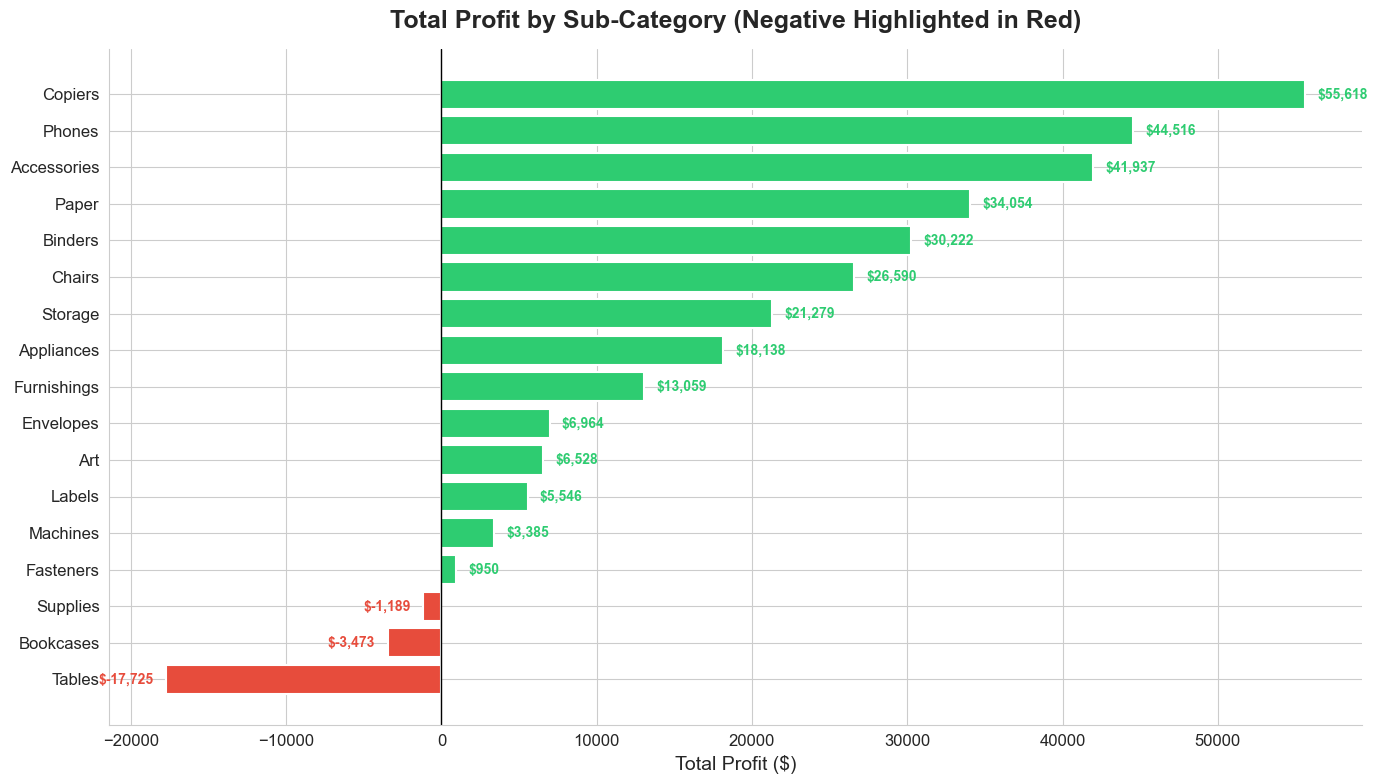

💾 Saved: chart1_profit_by_subcategory.png


In [14]:
# ─── CHART 1: Bar Chart — Profit by Sub-Category (highlight negatives) ───

profit_by_subcat = subcat_agg['Total_Profit'].sort_values()
bar_colors = ['#e74c3c' if v < 0 else '#2ecc71' for v in profit_by_subcat.values]

fig, ax = plt.subplots(figsize=(14, 8))
bars = ax.barh(profit_by_subcat.index, profit_by_subcat.values,
               color=bar_colors, edgecolor='white', linewidth=1.5)

# Add value labels
for bar, val in zip(bars, profit_by_subcat.values):
    offset = 800 if val >= 0 else -800
    ha = 'left' if val >= 0 else 'right'
    color = '#2ecc71' if val >= 0 else '#e74c3c'
    ax.text(val + offset, bar.get_y() + bar.get_height()/2,
            f'${val:,.0f}', va='center', ha=ha, fontsize=10,
            fontweight='bold', color=color)

# Zero line
ax.axvline(x=0, color='black', linewidth=1, linestyle='-')

ax.set_title('Total Profit by Sub-Category (Negative Highlighted in Red)',
             fontsize=18, fontweight='bold', pad=15)
ax.set_xlabel('Total Profit ($)', fontsize=14)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('chart1_profit_by_subcategory.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved: chart1_profit_by_subcategory.png')

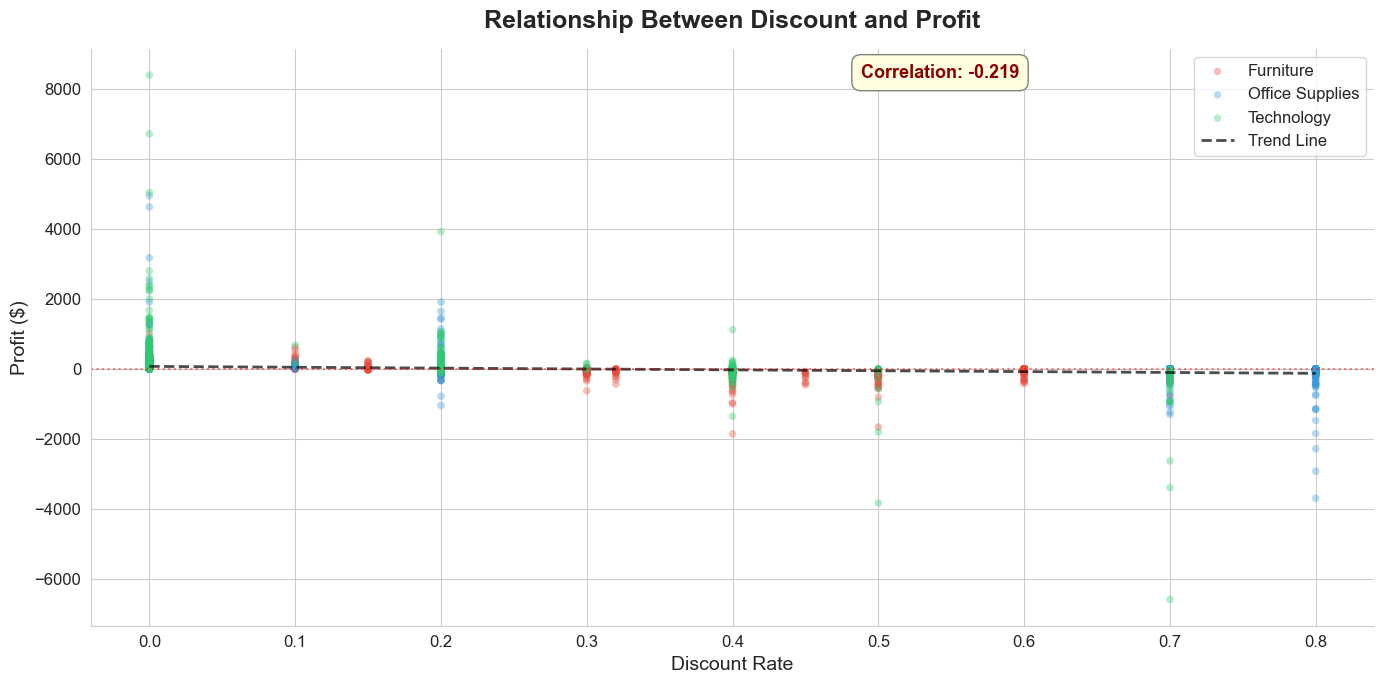

💾 Saved: chart2_discount_vs_profit.png


In [15]:
# ─── CHART 2: Scatter Plot — Discount vs Profit ───

fig, ax = plt.subplots(figsize=(14, 7))

# Color by category
cat_colors = {'Furniture': '#e74c3c', 'Office Supplies': '#3498db', 'Technology': '#2ecc71'}

for cat, color in cat_colors.items():
    mask = df['Category'] == cat
    ax.scatter(df.loc[mask, 'Discount'], df.loc[mask, 'Profit'],
              alpha=0.35, s=30, color=color, label=cat, edgecolors='none')

# Add trend line
z = np.polyfit(df['Discount'], df['Profit'], 1)
p = np.poly1d(z)
x_line = np.linspace(0, df['Discount'].max(), 100)
ax.plot(x_line, p(x_line), '--', color='black', linewidth=2, alpha=0.7, label='Trend Line')

# Zero profit line
ax.axhline(y=0, color='red', linestyle=':', alpha=0.5, linewidth=1.5)

# Correlation annotation
corr = df['Discount'].corr(df['Profit'])
ax.annotate(f'Correlation: {corr:.3f}', xy=(0.6, 0.95), xycoords='axes fraction',
            fontsize=13, fontweight='bold', color='darkred',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='lightyellow', edgecolor='gray'))

ax.set_title('Relationship Between Discount and Profit',
             fontsize=18, fontweight='bold', pad=15)
ax.set_xlabel('Discount Rate', fontsize=14)
ax.set_ylabel('Profit ($)', fontsize=14)
ax.legend(fontsize=12, loc='upper right')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('chart2_discount_vs_profit.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved: chart2_discount_vs_profit.png')

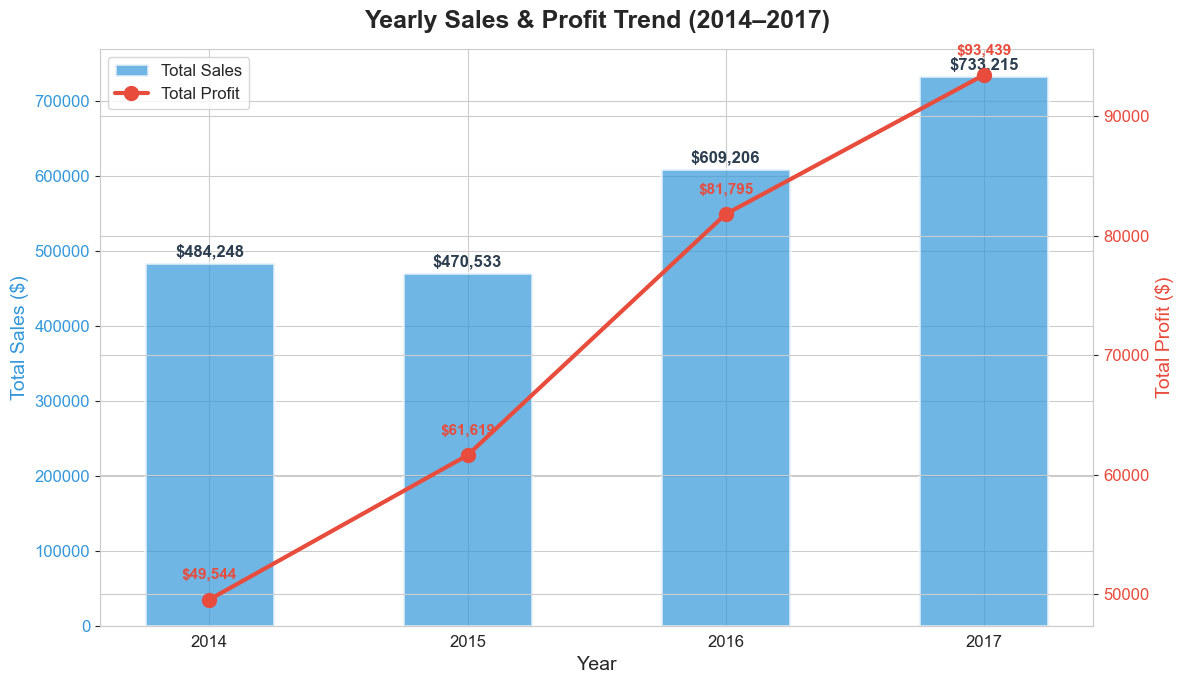

💾 Saved: chart3_yearly_sales_trend.png


In [16]:
# ─── CHART 3: Yearly Sales Trend Line ───

fig, ax1 = plt.subplots(figsize=(12, 7))

# Sales bars
bars = ax1.bar(yearly_trend.index, yearly_trend['Total_Sales'],
               color='#3498db', alpha=0.7, width=0.5, edgecolor='white',
               linewidth=2, label='Total Sales')

# Add value labels on bars
for bar, val in zip(bars, yearly_trend['Total_Sales']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000,
             f'${val:,.0f}', ha='center', va='bottom', fontweight='bold',
             fontsize=12, color='#2c3e50')

ax1.set_xlabel('Year', fontsize=14)
ax1.set_ylabel('Total Sales ($)', fontsize=14, color='#3498db')
ax1.tick_params(axis='y', labelcolor='#3498db')

# Profit line on secondary axis
ax2 = ax1.twinx()
ax2.plot(yearly_trend.index, yearly_trend['Total_Profit'],
         marker='o', color='#e74c3c', linewidth=3, markersize=10,
         label='Total Profit', zorder=5)

for x, y in zip(yearly_trend.index, yearly_trend['Total_Profit']):
    ax2.annotate(f'${y:,.0f}', xy=(x, y), xytext=(0, 15),
                textcoords='offset points', ha='center',
                fontsize=11, fontweight='bold', color='#e74c3c')

ax2.set_ylabel('Total Profit ($)', fontsize=14, color='#e74c3c')
ax2.tick_params(axis='y', labelcolor='#e74c3c')

ax1.set_title('Yearly Sales & Profit Trend (2014–2017)',
              fontsize=18, fontweight='bold', pad=15)
ax1.set_xticks(yearly_trend.index)

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=12)

ax1.spines['top'].set_visible(False)
plt.tight_layout()
plt.savefig('chart3_yearly_sales_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved: chart3_yearly_sales_trend.png')

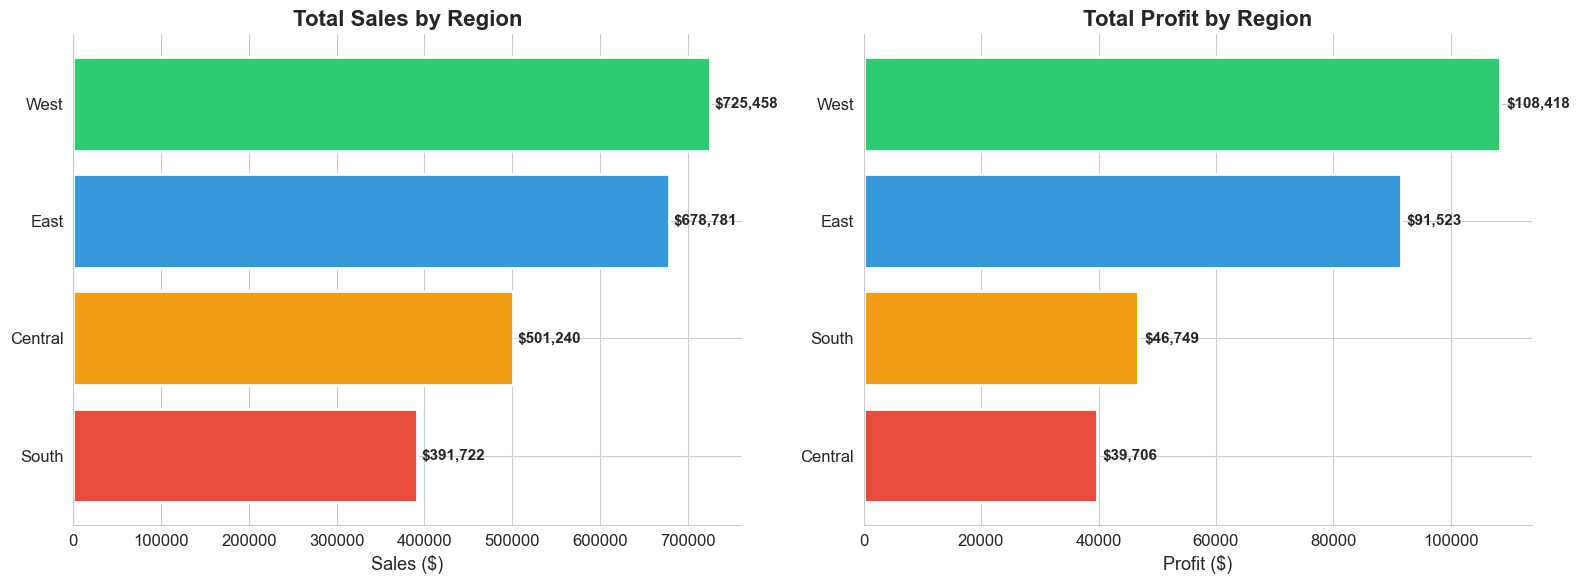

💾 Saved: chart4_region_sales_profit.png


In [17]:
# ─── CHART 4: Sales & Profit by Region ───

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Sales by Region
region_sorted = region_agg.sort_values('Total_Sales', ascending=True)
colors_region = ['#e74c3c', '#f39c12', '#3498db', '#2ecc71']
axes[0].barh(region_sorted.index, region_sorted['Total_Sales'],
             color=colors_region, edgecolor='white', linewidth=2)
for i, (idx, val) in enumerate(region_sorted['Total_Sales'].items()):
    axes[0].text(val + 5000, i, f'${val:,.0f}', va='center',
                fontweight='bold', fontsize=11)
axes[0].set_title('Total Sales by Region', fontsize=16, fontweight='bold')
axes[0].set_xlabel('Sales ($)', fontsize=13)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Profit by Region
region_profit = region_agg.sort_values('Total_Profit', ascending=True)
profit_colors = ['#e74c3c', '#f39c12', '#3498db', '#2ecc71']
axes[1].barh(region_profit.index, region_profit['Total_Profit'],
             color=profit_colors, edgecolor='white', linewidth=2)
for i, (idx, val) in enumerate(region_profit['Total_Profit'].items()):
    axes[1].text(val + 1000, i, f'${val:,.0f}', va='center',
                fontweight='bold', fontsize=11)
axes[1].set_title('Total Profit by Region', fontsize=16, fontweight='bold')
axes[1].set_xlabel('Profit ($)', fontsize=13)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('chart4_region_sales_profit.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved: chart4_region_sales_profit.png')

## 10. ⭐ Bonus Features

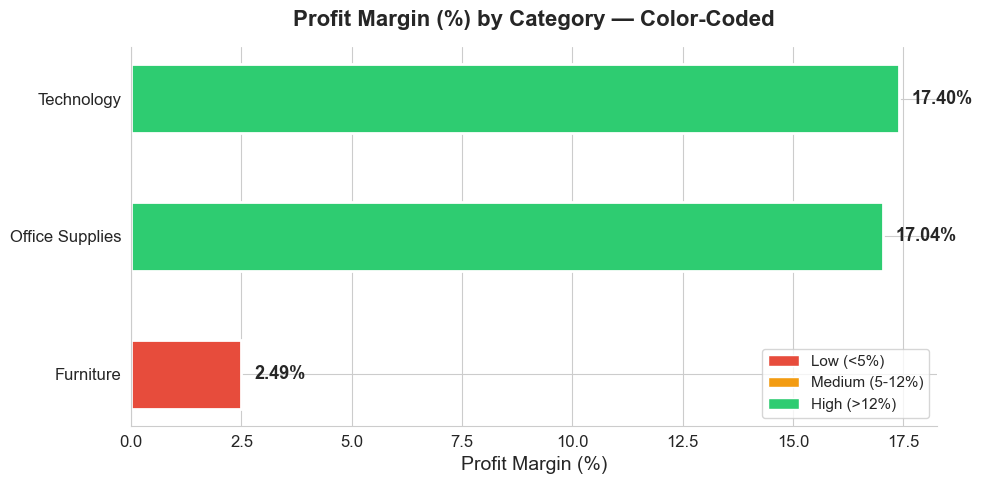

💾 Saved: chart5_profit_margin_category.png


In [18]:
# ─── BONUS 1: Profit Margin (%) per Category — Color-Coded Bar ───

cat_margin = category_agg[['Total_Sales', 'Total_Profit', 'Profit_Margin_%']].sort_values('Profit_Margin_%')

fig, ax = plt.subplots(figsize=(10, 5))

# Color-code by margin level
margin_colors = []
for m in cat_margin['Profit_Margin_%']:
    if m < 5:
        margin_colors.append('#e74c3c')   # Low margin = red
    elif m < 12:
        margin_colors.append('#f39c12')   # Medium = orange
    else:
        margin_colors.append('#2ecc71')   # High = green

bars = ax.barh(cat_margin.index, cat_margin['Profit_Margin_%'],
               color=margin_colors, edgecolor='white', linewidth=2, height=0.5)

for bar, val in zip(bars, cat_margin['Profit_Margin_%']):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}%', va='center', fontweight='bold', fontsize=13)

ax.set_title('Profit Margin (%) by Category — Color-Coded',
             fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Profit Margin (%)', fontsize=14)

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#e74c3c', label='Low (<5%)'),
    Patch(facecolor='#f39c12', label='Medium (5-12%)'),
    Patch(facecolor='#2ecc71', label='High (>12%)')
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('chart5_profit_margin_category.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved: chart5_profit_margin_category.png')

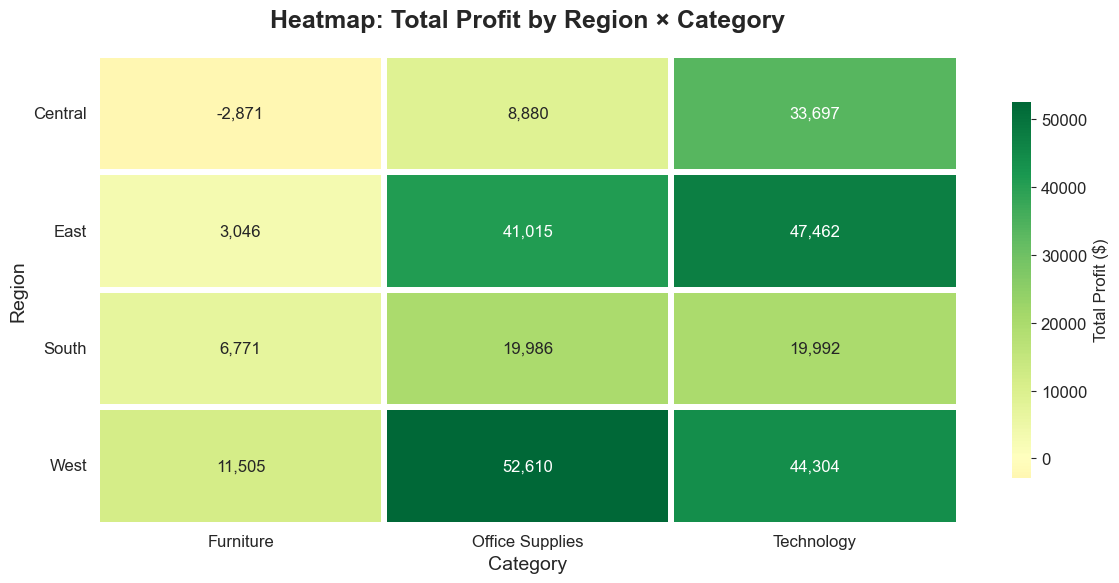

💾 Saved: chart6_heatmap_region_category.png


In [19]:
# ─── BONUS 2: Heatmap — Region vs Category (Total Profit) ───

profit_pivot = df.pivot_table(values='Profit', index='Region',
                              columns='Category', aggfunc='sum').round(2)

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(
    profit_pivot,
    annot=True, fmt=',.0f',
    cmap='RdYlGn',
    linewidths=3, linecolor='white',
    center=0,
    cbar_kws={'label': 'Total Profit ($)', 'shrink': 0.8},
    ax=ax
)

ax.set_title('Heatmap: Total Profit by Region × Category',
             fontsize=18, fontweight='bold', pad=20)
ax.set_xlabel('Category', fontsize=14)
ax.set_ylabel('Region', fontsize=14)
ax.tick_params(axis='x', rotation=0, labelsize=12)
ax.tick_params(axis='y', rotation=0, labelsize=12)

plt.tight_layout()
plt.savefig('chart6_heatmap_region_category.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved: chart6_heatmap_region_category.png')

## 11. 💡 4 Business Insights for Profit Improvement

---

### Insight 1: Tables Sub-Category Is a Major Profit Drain — Requires Intervention
**Tables** generates a significant loss (~-$17K), despite having substantial sales volume. The root cause is likely a combination of **high discounting** and **high shipping costs** for a bulky product. Management should either **raise prices, reduce discount rates, or negotiate better supplier terms** for Tables. If profitability cannot be restored, consider discontinuing or repositioning the product line.

### Insight 2: Heavy Discounts (>40%) Directly Destroy Profit
The scatter plot and discount analysis clearly show that orders with **discount rates above 40% almost always generate negative profit**. The correlation between Discount and Profit is strongly negative. Management should implement a **strict discount ceiling of 30%** and require manager approval for any discount beyond 20%. This single policy could recover tens of thousands in lost profit.

### Insight 3: West Region Leads Sales but East Leads Profit Margin
The **West** region generates the most revenue (~$725K), but it doesn't necessarily translate to the best profit margins. The **East** region achieves strong profitability relative to its sales. Management should **study the East region's pricing discipline and discount culture** and apply those best practices to the West and South, where over-discounting may be eroding margins.

### Insight 4: Technology Is the Profit Champion — Double Down
**Technology** not only generates the highest total profit but also the best **profit margin (~17%)**, compared to Furniture (just ~2%). The business should **allocate more shelf space, marketing budget, and sales incentives toward Technology products**, especially high-margin sub-categories like **Copiers** ($56K profit from just 149 sales). Meanwhile, **reduce Furniture's discounting aggressiveness** to prevent further margin erosion.

In [20]:
# ─── FINAL SUMMARY ───

print('\n' + '='*65)
print('📋 ANALYSIS SUMMARY')
print('='*65)
print(f'Total records analyzed:    {len(df):>10,}')
print(f'Date range:                {df["Order Date"].min().strftime("%Y-%m-%d")} → {df["Order Date"].max().strftime("%Y-%m-%d")}')
print(f'Total sales:               ${df["Sales"].sum():>14,.2f}')
print(f'Total profit:              ${df["Profit"].sum():>14,.2f}')
print(f'Overall profit margin:     {df["Profit"].sum()/df["Sales"].sum()*100:>13.2f}%')
print(f'Avg days to ship:          {df["days_to_ship"].mean():>14.1f}')
print(f'Regions:                   {df["Region"].nunique():>14}')
print(f'Categories:                {df["Category"].nunique():>14}')
print(f'Sub-categories:            {df["Sub-Category"].nunique():>14}')
print(f'Top region (sales):        {region_agg.index[0]:>14}')
print(f'Top category (profit):     {category_agg.sort_values("Total_Profit", ascending=False).index[0]:>14}')
print(f'Loss-making sub-cats:      {len(negative_profit):>14}')
print(f'Peak year (sales):         {int(yearly_trend["Total_Sales"].idxmax()):>14}')
print('='*65)
print('✅ Sales & Profit Analysis Complete!')


📋 ANALYSIS SUMMARY
Total records analyzed:         9,994
Date range:                2014-01-03 → 2017-12-30
Total sales:               $  2,297,200.86
Total profit:              $    286,397.02
Overall profit margin:             12.47%
Avg days to ship:                     4.0
Regions:                                4
Categories:                             3
Sub-categories:                        17
Top region (sales):                  West
Top category (profit):         Technology
Loss-making sub-cats:                   3
Peak year (sales):                   2017
✅ Sales & Profit Analysis Complete!
